开始运行 2D RBM 模拟...


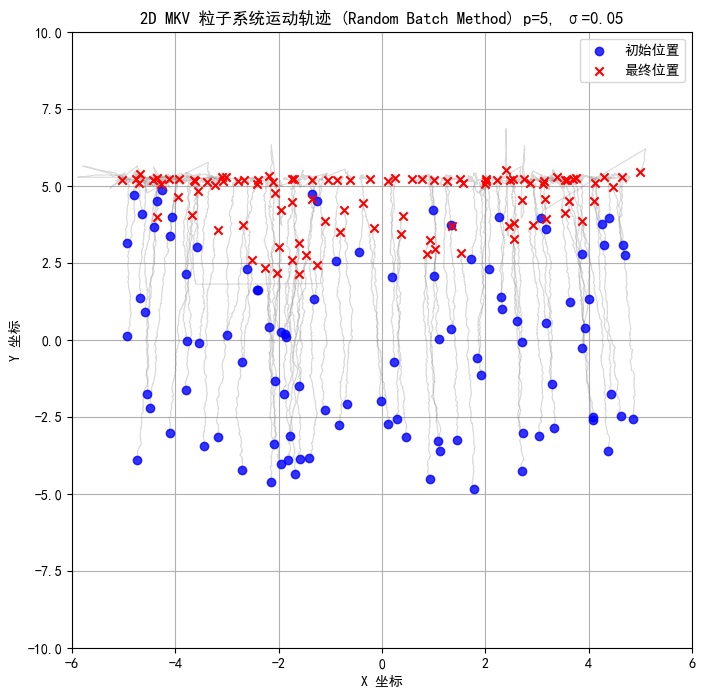

In [2]:
#1
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签（'SimHei' 是黑体）
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号

def rbm_mkv_2d(N, p, tau, T, b, K, sigma, X0=None):
    """
    针对 2 维空间优化的随机批处理方法 (RBM) 计算 McKean-Vlasov 方程。
    """
    d = 2  # 强制锁定为 2 维
    assert N % p == 0, "粒子总数 N 必须能被批次大小 p 整除"
    
    n = N // p
    M = int(T / tau)
    
    if X0 is None:
        # 在二维平面内随机初始化粒子 (例如在 -5 到 5 之间)
        X = np.random.uniform(-5, 5, (N, d))
    else:
        X = X0.copy()
        
    trajectories = np.zeros((M + 1, N, d))
    trajectories[0] = X
    
    for m in range(M):
        indices = np.random.permutation(N)
        batches = indices.reshape((n, p))
        X_next = np.zeros_like(X)
        
        for q in range(n):
            batch_idx = batches[q]
            X_batch = X[batch_idx] # 形状: (p, 2)
            
            # 计算批次内所有粒子对的向量差
            # diff 形状为 (p, p, 2)，其中 diff[i, j, :] = X_i - X_j (这是一个二维向量)
            diff = X_batch[:, np.newaxis, :] - X_batch[np.newaxis, :, :]
            
            # 计算二维核函数 K
            K_eval = K(diff) # 返回形状应为 (p, p, 2)
            
            # 将对角线（自己对自己的力）置为 [0, 0]
            for i in range(p):
                K_eval[i, i] = [0.0, 0.0]
                
            # 在 j 的维度上求和并取平均 (p > 1)
            F_batch = np.sum(K_eval, axis=1) / (p - 1)
            
            # 生成二维正态分布的布朗运动增量
            Z = np.random.randn(p, d)
            
            # 欧拉-丸山更新
            X_next[batch_idx] = (X_batch 
                                 + b(X_batch) * tau 
                                 + F_batch * tau 
                                 + sigma * np.sqrt(tau) * Z)
            
        X = X_next
        trajectories[m + 1] = X
        
    return trajectories

def b_2d(x):
        # x 形状: (p, 2)
        drift = np.zeros_like(x)
        
        # 1. 生物本能：恒定的向上游动速度 (趋地性/趋光性)
        v_swim = 2.0 
        drift[:, 1] = v_swim
        
        # 2. 容器边界排斥力 (假设容器范围是 x:[-5, 5], y:[-5, 5])
        # 使用简单的非线性弹簧力代表墙壁和水面的阻挡
        wall_stiffness = 5.0
        # 限制左右边界
        drift[:, 0] += -wall_stiffness * np.maximum(x[:, 0] - 5, 0) 
        drift[:, 0] += -wall_stiffness * np.minimum(x[:, 0] + 5, 0)
        # 限制底部和顶部(水面)
        drift[:, 1] += -wall_stiffness * np.maximum(x[:, 1] - 5, 0) 
        drift[:, 1] += -wall_stiffness * np.minimum(x[:, 1] + 5, 0)
        
        return drift

def K_2d(diff):
        # diff 形状: (p, p, 2), diff = X_i - X_j
        # 计算距离平方
        norm_sq = np.sum(diff**2, axis=-1, keepdims=True) # 形状: (p, p, 1)
        
        # 防止重合并控制影响半径的平滑因子
        epsilon = 1.0 
        denominator = epsilon + norm_sq 
        
        force = np.zeros_like(diff)
        
        # 1. 垂直方向 (Y)：局部高密度引起的向下拖拽流体速度 (沉降羽流)
        # 因为微生物比水重，邻居的存在会产生向下的速度场
        downward_strength = 6.0
        force[..., 1] = -downward_strength / denominator[..., 0]
        
        # 2. 水平方向 (X)：流体的卷吸效应 (Entrainment)
        # 向下的水流会将两侧的粒子吸向羽流中心
        # -diff[..., 0] 指向邻居的 X 方向
        entrainment_strength = 3.0
        force[..., 0] = -entrainment_strength * diff[..., 0] / (denominator[..., 0]**1.5)
        
        # 3. 体积排斥 (防止粒子完全塌缩到同一点)
        repulsion_strength = 0.5
        repulsion = diff / (norm_sq + 1e-5)**1.5
        force += repulsion_strength * repulsion
        
        return force
# ==========================================
# 2D 场景的具体函数定义与测试
# ==========================================
if __name__ == "__main__":


    # 设置参数
    N_particles = 100
    p_batch = 5      
    tau_step = 0.01
    T_total = 5.0      # 延长模拟时间以观察聚集效应
    sigma_diff = 0.05  # 噪声强度

    # ==========================================
    # 固定初始位置以进行控制变量法
    # ==========================================
    np.random.seed(42)  # 设定一个固定的随机种子
    fixed_X0 = np.random.uniform(-5, 5, (N_particles, 2))  # 提前生成固定的初始位置
    np.random.seed(None)  # 恢复系统的随机性，确保后续的批次打乱和噪声不受固定种子影响

    print("开始运行 2D RBM 模拟...")
    
    # 传入固定的初始位置 X0=fixed_X0
    traj = rbm_mkv_2d(N=N_particles, p=p_batch, tau=tau_step, T=T_total, 
                      b=b_2d, K=K_2d, sigma=sigma_diff, X0=fixed_X0)
    
    # --- 简单的二维轨迹可视化 (仅绘制初始和最终状态) ---
    plt.figure(figsize=(8, 8))
    # --- 二维轨迹可视化 ---
    
    # 提取初始状态 (m=0) 和 最终状态 (m=M)
    X_start = traj[0]
    X_end = traj[-1]
    
    # 🌟 新增：循环绘制每个粒子的完整运动轨迹
    # traj[:, i, 0] 取出第 i 个粒子在所有时间的 X 坐标
    # traj[:, i, 1] 取出第 i 个粒子在所有时间的 Y 坐标
    for i in range(N_particles):
        plt.plot(traj[:, i, 0], traj[:, i, 1], color='gray', alpha=0.3, linewidth=0.8)
    
    # 绘制起点和终点 (zorder=5 确保散点画在轨迹线条的上方)
    plt.scatter(X_start[:, 0], X_start[:, 1], c='blue', alpha=0.8, label='初始位置', zorder=5)
    plt.scatter(X_end[:, 0], X_end[:, 1], c='red', marker='x', label='最终位置', zorder=5)
    
    plt.title("2D MKV 粒子系统运动轨迹 (Random Batch Method) p={}".format(p_batch) + ", σ={}".format(sigma_diff))
    plt.xlabel("X 坐标")
    plt.ylabel("Y 坐标")
    plt.legend()
    plt.grid(True)
    plt.xlim(-6, 6)  # 根据您想看的中心范围调整
    plt.ylim(-10, 10) 
    plt.show()
    # 提取初始状态 (m=0) 和 最终状态 (m=M)

正在运行 Ground Truth (p=N)...
正在运行 RBM 系综 (10 次独立模拟, p=50)...
  RBM 运行 1/10
  RBM 运行 2/10
  RBM 运行 3/10
  RBM 运行 4/10
  RBM 运行 5/10
  RBM 运行 6/10
  RBM 运行 7/10
  RBM 运行 8/10
  RBM 运行 9/10
  RBM 运行 10/10


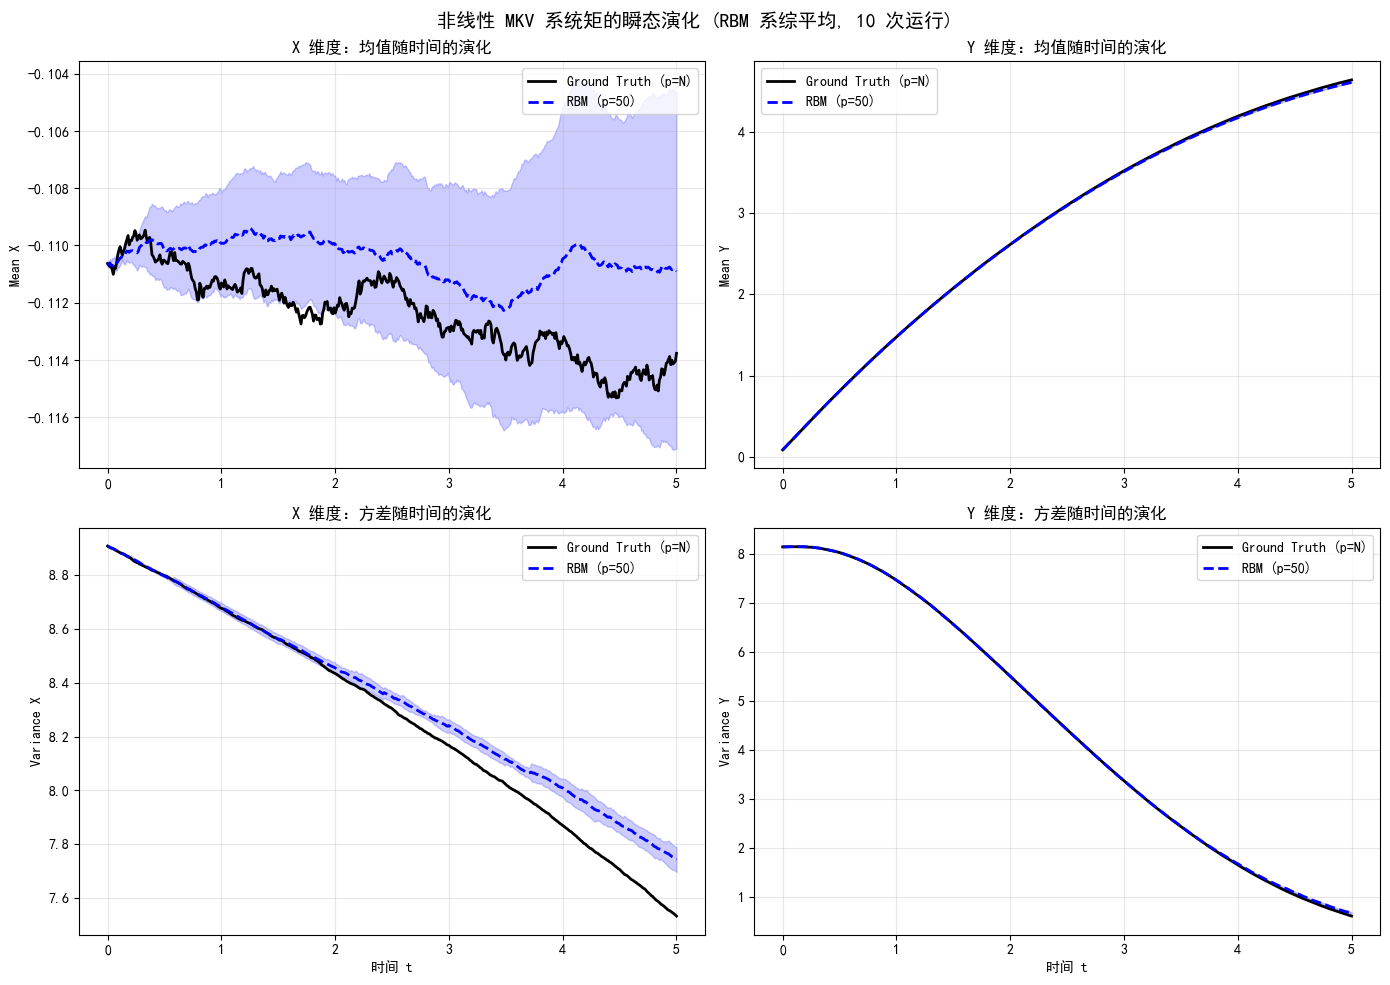

In [3]:
def run_single_simulation(N, p, tau, T, b, K, sigma, X0, seed_offset):
    """运行一次模拟，返回时间轴、均值轨迹、方差轨迹"""
    np.random.seed(42 + seed_offset)   # 固定初始位置种子 + 偏移，保证每次随机路径不同
    fixed_X0 = X0.copy()
    
    traj = rbm_mkv_2d(N=N, p=p, tau=tau, T=T, b=b, K=K, sigma=sigma, X0=fixed_X0)
    
    M = int(T / tau)
    time_axis = np.linspace(0, T, M + 1)
    
    mean_traj = np.mean(traj, axis=1)  # (M+1, 2)
    var_traj  = np.var(traj, axis=1)   # (M+1, 2)
    
    return time_axis, mean_traj, var_traj, traj

# ==========================================
# 主程序
# ==========================================
if __name__ == "__main__":
    # ----- 参数设置 -----
    N_particles = 1000
    p_rbm = 50               # RBM 批次大小
    p_gt = N_particles      # 全耦合 Ground Truth
    tau_step = 0.01
    T_total = 5.0
    sigma_diff = 0.05

    n_ensemble = 10         # 系综平均次数（建议 5~20，可自行调整）

    # ----- 固定初始位置（所有模拟共用）-----
    np.random.seed(42)
    fixed_X0 = np.random.uniform(-5, 5, (N_particles, 2))

    # ----- 运行 Ground Truth (p=N) -----
    print("正在运行 Ground Truth (p=N)...")
    time_gt, mean_gt, var_gt, traj_gt = run_single_simulation(
        N=N_particles, p=p_gt, tau=tau_step, T=T_total,
        b=b_2d, K=K_2d, sigma=sigma_diff, X0=fixed_X0, seed_offset=0
    )

    # ----- 运行 RBM 系综（多次独立模拟）-----
    print(f"正在运行 RBM 系综 ({n_ensemble} 次独立模拟, p={p_rbm})...")
    rbm_means = []
    rbm_vars  = []
    # 保留最后一次 RBM 的轨迹用于微观轨迹可视化
    
    for run_id in range(n_ensemble):
        print(f"  RBM 运行 {run_id+1}/{n_ensemble}")
        _, mean_rbm, var_rbm, traj_rbm = run_single_simulation(
            N=N_particles, p=p_rbm, tau=tau_step, T=T_total,
            b=b_2d, K=K_2d, sigma=sigma_diff, X0=fixed_X0, seed_offset=run_id
        )
        rbm_means.append(mean_rbm)
        rbm_vars.append(var_rbm)


    # 转换为数组并计算系综统计量
    rbm_means = np.array(rbm_means)  # (n_ensemble, M+1, 2)
    rbm_vars  = np.array(rbm_vars)
    
    mean_rbm_avg = np.mean(rbm_means, axis=0)
    mean_rbm_std = np.std(rbm_means, axis=0)
    var_rbm_avg  = np.mean(rbm_vars, axis=0)
    var_rbm_std  = np.std(rbm_vars, axis=0)

    # ==========================================
    # 图1：统计精度验证（矩的瞬态演化对比）
    # ==========================================
    fig1, axs = plt.subplots(2, 2, figsize=(14, 10))
    fig1.suptitle(f"非线性 MKV 系统矩的瞬态演化 (RBM 系综平均, {n_ensemble} 次运行)", fontsize=14)

    # X 均值
    axs[0, 0].plot(time_gt, mean_gt[:, 0], 'k-', linewidth=2, label='Ground Truth (p=N)')
    axs[0, 0].plot(time_gt, mean_rbm_avg[:, 0], 'b--', linewidth=2, label=f'RBM (p={p_rbm})')
    axs[0, 0].fill_between(time_gt,
                           mean_rbm_avg[:, 0] - mean_rbm_std[:, 0],
                           mean_rbm_avg[:, 0] + mean_rbm_std[:, 0],
                           color='blue', alpha=0.2)
    axs[0, 0].set_title('X 维度：均值随时间的演化')
    axs[0, 0].set_ylabel('Mean X')
    axs[0, 0].legend()
    axs[0, 0].grid(True, alpha=0.3)

    # Y 均值
    axs[0, 1].plot(time_gt, mean_gt[:, 1], 'k-', linewidth=2, label='Ground Truth (p=N)')
    axs[0, 1].plot(time_gt, mean_rbm_avg[:, 1], 'b--', linewidth=2, label=f'RBM (p={p_rbm})')
    axs[0, 1].fill_between(time_gt,
                           mean_rbm_avg[:, 1] - mean_rbm_std[:, 1],
                           mean_rbm_avg[:, 1] + mean_rbm_std[:, 1],
                           color='blue', alpha=0.2)
    axs[0, 1].set_title('Y 维度：均值随时间的演化')
    axs[0, 1].set_ylabel('Mean Y')
    axs[0, 1].legend()
    axs[0, 1].grid(True, alpha=0.3)

    # X 方差
    axs[1, 0].plot(time_gt, var_gt[:, 0], 'k-', linewidth=2, label='Ground Truth (p=N)')
    axs[1, 0].plot(time_gt, var_rbm_avg[:, 0], 'b--', linewidth=2, label=f'RBM (p={p_rbm})')
    axs[1, 0].fill_between(time_gt,
                           var_rbm_avg[:, 0] - var_rbm_std[:, 0],
                           var_rbm_avg[:, 0] + var_rbm_std[:, 0],
                           color='blue', alpha=0.2)
    axs[1, 0].set_title('X 维度：方差随时间的演化')
    axs[1, 0].set_ylabel('Variance X')
    axs[1, 0].set_xlabel('时间 t')
    axs[1, 0].legend()
    axs[1, 0].grid(True, alpha=0.3)

    # Y 方差
    axs[1, 1].plot(time_gt, var_gt[:, 1], 'k-', linewidth=2, label='Ground Truth (p=N)')
    axs[1, 1].plot(time_gt, var_rbm_avg[:, 1], 'b--', linewidth=2, label=f'RBM (p={p_rbm})')
    axs[1, 1].fill_between(time_gt,
                           var_rbm_avg[:, 1] - var_rbm_std[:, 1],
                           var_rbm_avg[:, 1] + var_rbm_std[:, 1],
                           color='blue', alpha=0.2)
    axs[1, 1].set_title('Y 维度：方差随时间的演化')
    axs[1, 1].set_ylabel('Variance Y')
    axs[1, 1].set_xlabel('时间 t')
    axs[1, 1].legend()
    axs[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

正在运行 Ground Truth (p=N)...
正在运行 RBM 系综 (10 次独立模拟, p=20)...
  RBM 运行 1/10
  RBM 运行 2/10
  RBM 运行 3/10
  RBM 运行 4/10
  RBM 运行 5/10
  RBM 运行 6/10
  RBM 运行 7/10
  RBM 运行 8/10
  RBM 运行 9/10
  RBM 运行 10/10


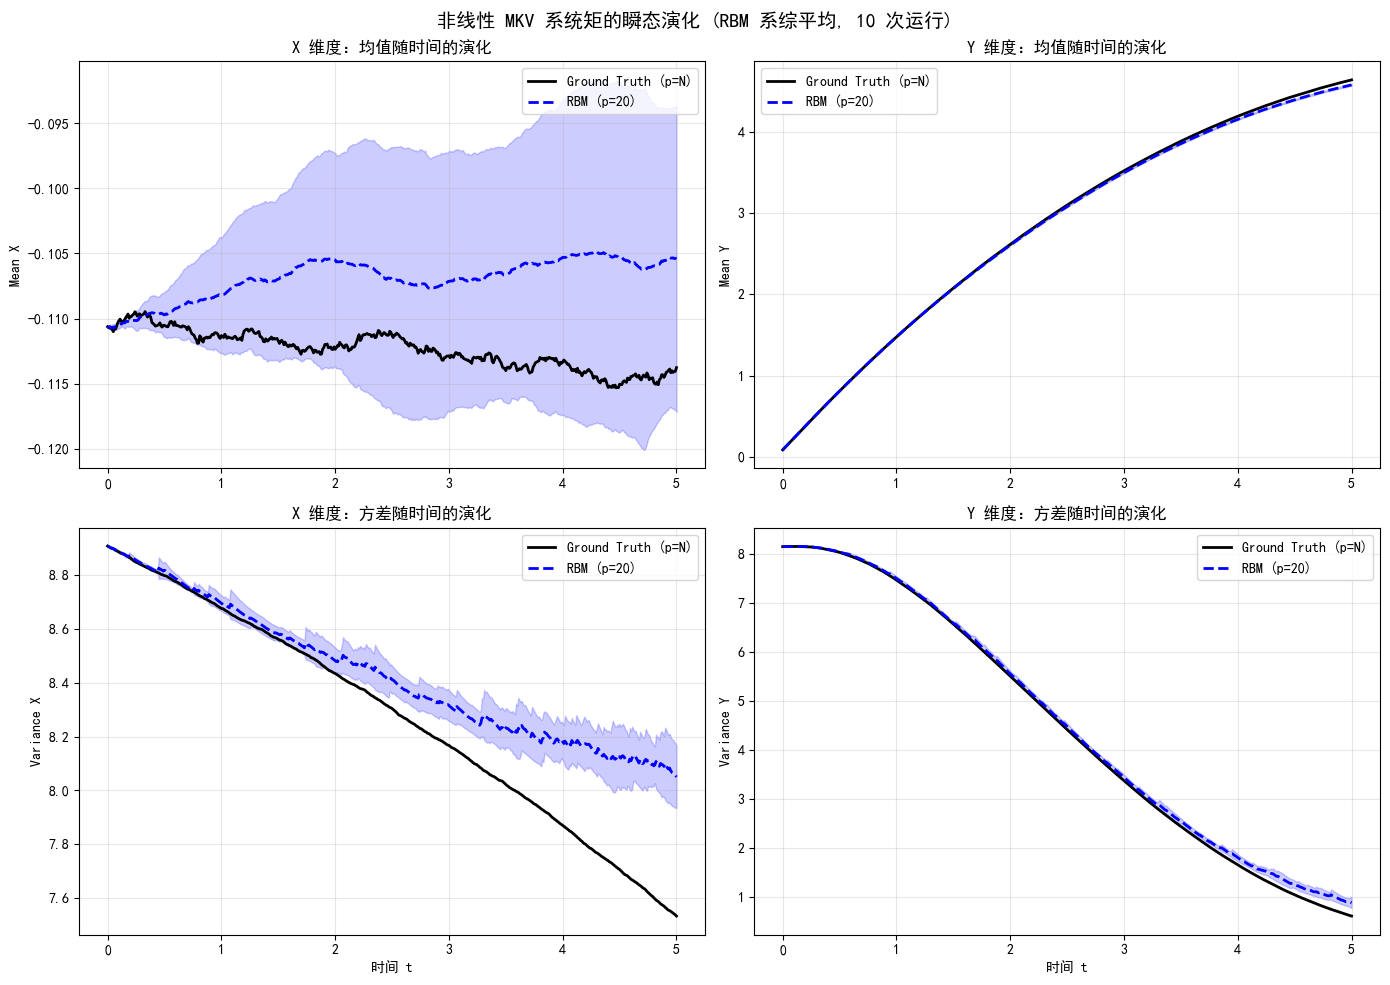

In [58]:
def run_single_simulation(N, p, tau, T, b, K, sigma, X0, seed_offset):
    """运行一次模拟，返回时间轴、均值轨迹、方差轨迹"""
    np.random.seed(42 + seed_offset)   # 固定初始位置种子 + 偏移，保证每次随机路径不同
    fixed_X0 = X0.copy()
    
    traj = rbm_mkv_2d(N=N, p=p, tau=tau, T=T, b=b, K=K, sigma=sigma, X0=fixed_X0)
    
    M = int(T / tau)
    time_axis = np.linspace(0, T, M + 1)
    
    mean_traj = np.mean(traj, axis=1)  # (M+1, 2)
    var_traj  = np.var(traj, axis=1)   # (M+1, 2)
    
    return time_axis, mean_traj, var_traj, traj

# ==========================================
# 主程序
# ==========================================
if __name__ == "__main__":
    # ----- 参数设置 -----
    N_particles = 1000
    p_rbm = 20               # RBM 批次大小
    p_gt = N_particles      # 全耦合 Ground Truth
    tau_step = 0.01
    T_total = 5.0
    sigma_diff = 0.05

    n_ensemble = 10         # 系综平均次数（建议 5~20，可自行调整）

    # ----- 固定初始位置（所有模拟共用）-----
    np.random.seed(42)
    fixed_X0 = np.random.uniform(-5, 5, (N_particles, 2))

    # ----- 运行 Ground Truth (p=N) -----
    print("正在运行 Ground Truth (p=N)...")
    time_gt, mean_gt, var_gt, traj_gt = run_single_simulation(
        N=N_particles, p=p_gt, tau=tau_step, T=T_total,
        b=b_2d, K=K_2d, sigma=sigma_diff, X0=fixed_X0, seed_offset=0
    )

    # ----- 运行 RBM 系综（多次独立模拟）-----
    print(f"正在运行 RBM 系综 ({n_ensemble} 次独立模拟, p={p_rbm})...")
    rbm_means = []
    rbm_vars  = []
    # 保留最后一次 RBM 的轨迹用于微观轨迹可视化
    
    for run_id in range(n_ensemble):
        print(f"  RBM 运行 {run_id+1}/{n_ensemble}")
        _, mean_rbm, var_rbm, traj_rbm = run_single_simulation(
            N=N_particles, p=p_rbm, tau=tau_step, T=T_total,
            b=b_2d, K=K_2d, sigma=sigma_diff, X0=fixed_X0, seed_offset=run_id
        )
        rbm_means.append(mean_rbm)
        rbm_vars.append(var_rbm)


    # 转换为数组并计算系综统计量
    rbm_means = np.array(rbm_means)  # (n_ensemble, M+1, 2)
    rbm_vars  = np.array(rbm_vars)
    
    mean_rbm_avg = np.mean(rbm_means, axis=0)
    mean_rbm_std = np.std(rbm_means, axis=0)
    var_rbm_avg  = np.mean(rbm_vars, axis=0)
    var_rbm_std  = np.std(rbm_vars, axis=0)

    # ==========================================
    # 图1：统计精度验证（矩的瞬态演化对比）
    # ==========================================
    fig1, axs = plt.subplots(2, 2, figsize=(14, 10))
    fig1.suptitle(f"非线性 MKV 系统矩的瞬态演化 (RBM 系综平均, {n_ensemble} 次运行)", fontsize=14)

    # X 均值
    axs[0, 0].plot(time_gt, mean_gt[:, 0], 'k-', linewidth=2, label='Ground Truth (p=N)')
    axs[0, 0].plot(time_gt, mean_rbm_avg[:, 0], 'b--', linewidth=2, label=f'RBM (p={p_rbm})')
    axs[0, 0].fill_between(time_gt,
                           mean_rbm_avg[:, 0] - mean_rbm_std[:, 0],
                           mean_rbm_avg[:, 0] + mean_rbm_std[:, 0],
                           color='blue', alpha=0.2)
    axs[0, 0].set_title('X 维度：均值随时间的演化')
    axs[0, 0].set_ylabel('Mean X')
    axs[0, 0].legend()
    axs[0, 0].grid(True, alpha=0.3)

    # Y 均值
    axs[0, 1].plot(time_gt, mean_gt[:, 1], 'k-', linewidth=2, label='Ground Truth (p=N)')
    axs[0, 1].plot(time_gt, mean_rbm_avg[:, 1], 'b--', linewidth=2, label=f'RBM (p={p_rbm})')
    axs[0, 1].fill_between(time_gt,
                           mean_rbm_avg[:, 1] - mean_rbm_std[:, 1],
                           mean_rbm_avg[:, 1] + mean_rbm_std[:, 1],
                           color='blue', alpha=0.2)
    axs[0, 1].set_title('Y 维度：均值随时间的演化')
    axs[0, 1].set_ylabel('Mean Y')
    axs[0, 1].legend()
    axs[0, 1].grid(True, alpha=0.3)

    # X 方差
    axs[1, 0].plot(time_gt, var_gt[:, 0], 'k-', linewidth=2, label='Ground Truth (p=N)')
    axs[1, 0].plot(time_gt, var_rbm_avg[:, 0], 'b--', linewidth=2, label=f'RBM (p={p_rbm})')
    axs[1, 0].fill_between(time_gt,
                           var_rbm_avg[:, 0] - var_rbm_std[:, 0],
                           var_rbm_avg[:, 0] + var_rbm_std[:, 0],
                           color='blue', alpha=0.2)
    axs[1, 0].set_title('X 维度：方差随时间的演化')
    axs[1, 0].set_ylabel('Variance X')
    axs[1, 0].set_xlabel('时间 t')
    axs[1, 0].legend()
    axs[1, 0].grid(True, alpha=0.3)

    # Y 方差
    axs[1, 1].plot(time_gt, var_gt[:, 1], 'k-', linewidth=2, label='Ground Truth (p=N)')
    axs[1, 1].plot(time_gt, var_rbm_avg[:, 1], 'b--', linewidth=2, label=f'RBM (p={p_rbm})')
    axs[1, 1].fill_between(time_gt,
                           var_rbm_avg[:, 1] - var_rbm_std[:, 1],
                           var_rbm_avg[:, 1] + var_rbm_std[:, 1],
                           color='blue', alpha=0.2)
    axs[1, 1].set_title('Y 维度：方差随时间的演化')
    axs[1, 1].set_ylabel('Variance Y')
    axs[1, 1].set_xlabel('时间 t')
    axs[1, 1].legend()
    axs[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

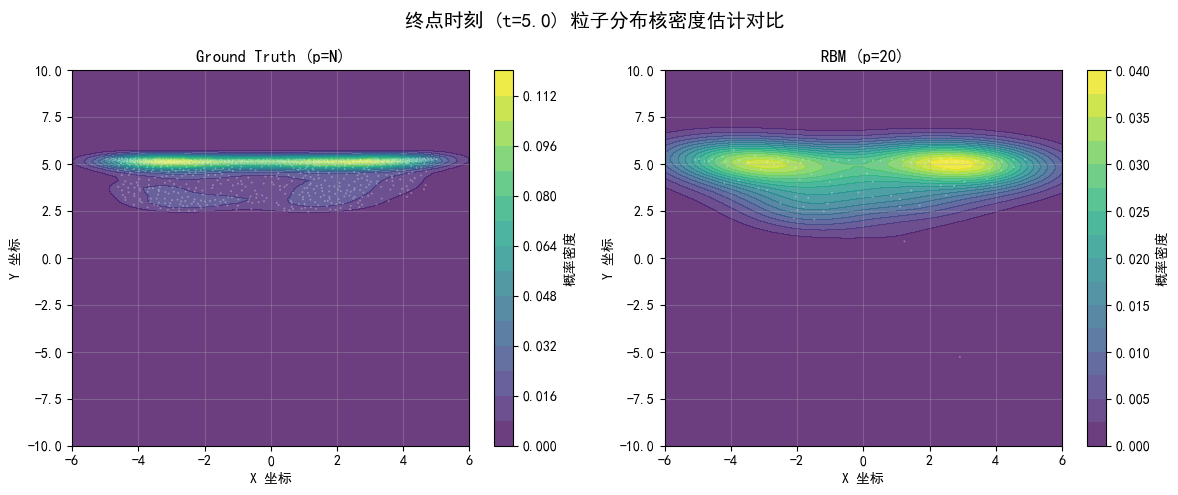

In [59]:
# 需在文件开头导入
from scipy.stats import gaussian_kde

# ==========================================
# 图3：终点时刻二维核密度估计对比
# ==========================================
fig3, axes = plt.subplots(1, 2, figsize=(12, 5))
fig3.suptitle(f"终点时刻 (t={T_total}) 粒子分布核密度估计对比", fontsize=14)

# 提取终点位置
X_gt_end = traj_gt[-1]      # (N, 2)
X_rbm_end = last_traj_rbm[-1]  # (N, 2)

# 公共网格范围
xmin, xmax = -6, 6
ymin, ymax = -10, 10

for ax, X, title in zip(axes, [X_gt_end, X_rbm_end], 
                        ['Ground Truth (p=N)', f'RBM (p={p_rbm})']):
    # 二维核密度估计
    kde = gaussian_kde(X.T)  # 输入形状需为 (2, N)
    xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
    positions = np.vstack([xx.ravel(), yy.ravel()])
    zz = np.reshape(kde(positions).T, xx.shape)
    
    # 绘制等高线
    cf = ax.contourf(xx, yy, zz, levels=15, cmap='viridis', alpha=0.8)
    ax.scatter(X[:, 0], X[:, 1], c='white', s=2, alpha=0.3, edgecolors='none')
    ax.set_title(title)
    ax.set_xlabel("X 坐标")
    ax.set_ylabel("Y 坐标")
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.grid(True, alpha=0.3)
    plt.colorbar(cf, ax=ax, label='概率密度')

plt.tight_layout()

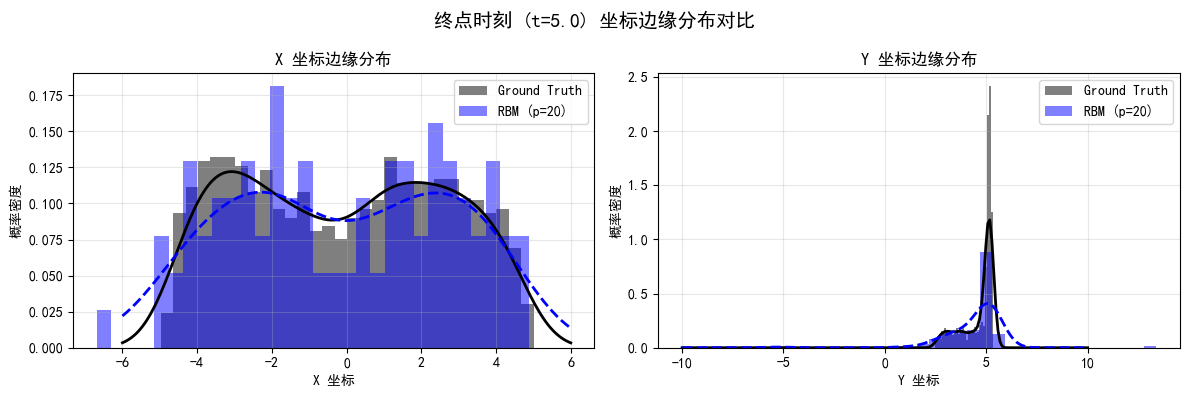

In [60]:
# ==========================================
# 图4：终点时刻边缘直方图对比
# ==========================================
fig4, axes = plt.subplots(1, 2, figsize=(12, 4))
fig4.suptitle(f"终点时刻 (t={T_total}) 坐标边缘分布对比", fontsize=14)

# X 坐标分布
ax = axes[0]
ax.hist(X_gt_end[:, 0], bins=30, density=True, alpha=0.5, color='black', label='Ground Truth')
ax.hist(X_rbm_end[:, 0], bins=30, density=True, alpha=0.5, color='blue', label=f'RBM (p={p_rbm})')
# 可选：叠加核密度估计曲线
kde_gt_x = gaussian_kde(X_gt_end[:, 0])
kde_rbm_x = gaussian_kde(X_rbm_end[:, 0])
x_plot = np.linspace(xmin, xmax, 200)
ax.plot(x_plot, kde_gt_x(x_plot), 'k-', linewidth=2)
ax.plot(x_plot, kde_rbm_x(x_plot), 'b--', linewidth=2)
ax.set_title('X 坐标边缘分布')
ax.set_xlabel('X 坐标')
ax.set_ylabel('概率密度')
ax.legend()
ax.grid(True, alpha=0.3)

# Y 坐标分布
ax = axes[1]
ax.hist(X_gt_end[:, 1], bins=30, density=True, alpha=0.5, color='black', label='Ground Truth')
ax.hist(X_rbm_end[:, 1], bins=30, density=True, alpha=0.5, color='blue', label=f'RBM (p={p_rbm})')
kde_gt_y = gaussian_kde(X_gt_end[:, 1])
kde_rbm_y = gaussian_kde(X_rbm_end[:, 1])
y_plot = np.linspace(ymin, ymax, 200)
ax.plot(y_plot, kde_gt_y(y_plot), 'k-', linewidth=2)
ax.plot(y_plot, kde_rbm_y(y_plot), 'b--', linewidth=2)
ax.set_title('Y 坐标边缘分布')
ax.set_xlabel('Y 坐标')
ax.set_ylabel('概率密度')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()

时间复杂度测试：RBM (p=20) vs 全耦合 (p=N)

当前粒子数 N = 100
  全耦合 (p=N)   : 平均单步耗时 = 8.8215e-04 s
  RBM (p=20)    : 平均单步耗时 = 5.0290e-04 s
  加速比 (全耦合 / RBM) = 1.75x

当前粒子数 N = 200
  全耦合 (p=N)   : 平均单步耗时 = 3.9108e-03 s
  RBM (p=20)    : 平均单步耗时 = 9.0942e-04 s
  加速比 (全耦合 / RBM) = 4.30x

当前粒子数 N = 500
  全耦合 (p=N)   : 平均单步耗时 = 2.7036e-02 s
  RBM (p=20)    : 平均单步耗时 = 2.3239e-03 s
  加速比 (全耦合 / RBM) = 11.63x

当前粒子数 N = 1000
  全耦合 (p=N)   : 平均单步耗时 = 1.0842e-01 s
  RBM (p=20)    : 平均单步耗时 = 4.3064e-03 s
  加速比 (全耦合 / RBM) = 25.18x

当前粒子数 N = 2000
  全耦合 (p=N)   : 平均单步耗时 = 3.9756e-01 s
  RBM (p=20)    : 平均单步耗时 = 8.9342e-03 s
  加速比 (全耦合 / RBM) = 44.50x

当前粒子数 N = 4000
  全耦合 (p=N)   : 平均单步耗时 = 1.7715e+00 s
  RBM (p=20)    : 平均单步耗时 = 1.9134e-02 s
  加速比 (全耦合 / RBM) = 92.58x

当前粒子数 N = 8000
  全耦合 (p=N)   : 平均单步耗时 = 7.8967e+00 s
  RBM (p=20)    : 平均单步耗时 = 4.1293e-02 s
  加速比 (全耦合 / RBM) = 191.24x


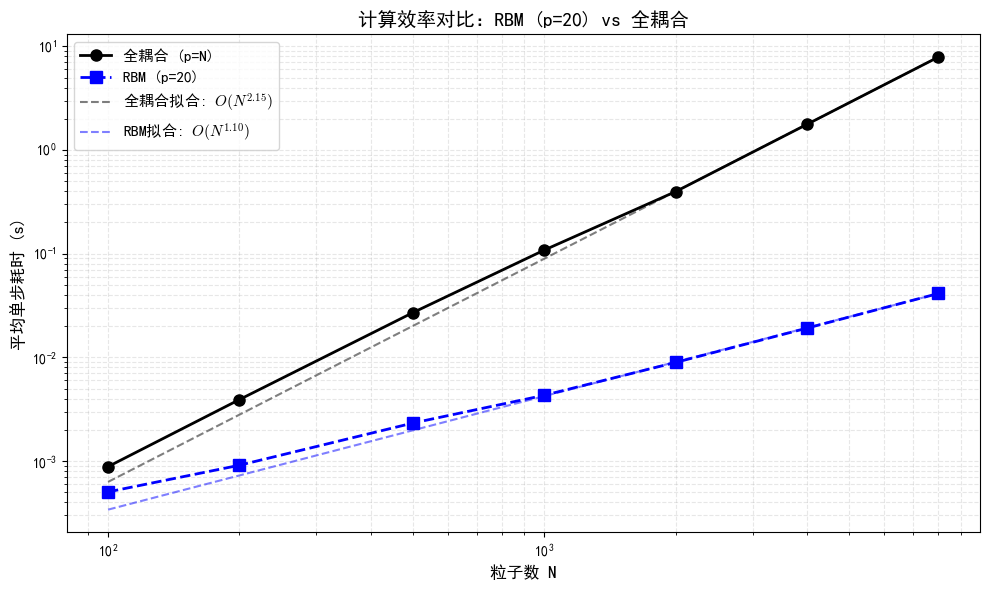


幂律拟合结果 (t = a * N^b):
全耦合: a = 3.09e-08, b = 2.15
RBM   : a = 2.19e-06, b = 1.10


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# 解决负号显示为方块或报错的问题
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['mathtext.fontset'] = 'cm' # 使用 Computer Modern 字体渲染数学符号
# ==========================================
# RBM 算法框架（与之前保持一致）
# ==========================================
def rbm_mkv_2d_single_step(X, p, b, K, sigma, tau):
    """执行一次 RBM 更新，返回更新后的 X 和单步耗时"""
    N, d = X.shape
    assert N % p == 0
    n = N // p

    start = time.perf_counter()
    indices = np.random.permutation(N)
    batches = indices.reshape((n, p))
    X_next = np.zeros_like(X)

    for q in range(n):
        batch_idx = batches[q]
        X_batch = X[batch_idx]
        diff = X_batch[:, np.newaxis, :] - X_batch[np.newaxis, :, :]
        K_eval = K(diff)
        for i in range(p):
            K_eval[i, i] = [0.0, 0.0]
        if p > 1:
            F_batch = np.sum(K_eval, axis=1) / (p - 1)
        else:
            F_batch = np.zeros_like(X_batch)
        Z = np.random.randn(p, d)
        X_next[batch_idx] = (X_batch + b(X_batch) * tau + F_batch * tau
                             + sigma * np.sqrt(tau) * Z)
    end = time.perf_counter()
    return X_next, end - start


def all_pair_single_step(X, b, K, sigma, tau):
    """全耦合单步更新（p=N），返回更新后的 X 和单步耗时"""
    N, d = X.shape
    start = time.perf_counter()
    diff = X[:, np.newaxis, :] - X[np.newaxis, :, :]
    K_eval = K(diff)
    for i in range(N):
        K_eval[i, i] = [0.0, 0.0]
    F = np.sum(K_eval, axis=1) / (N - 1)
    Z = np.random.randn(N, d)
    X_next = X + b(X) * tau + F * tau + sigma * np.sqrt(tau) * Z
    end = time.perf_counter()
    return X_next, end - start


# ==========================================
# 核函数定义（与您先前代码一致）
# =========================================


# ==========================================
# 主测试程序
# ==========================================
if __name__ == "__main__":
    # 测试参数
    p_rbm = 20                # RBM 固定批次大小
    tau = 0.01
    sigma = 0.05
    N_list = [100, 200, 500, 1000, 2000, 4000, 8000]  # 粒子数序列
    warmup_steps = 5          # 预热步数（不计时，消除初始化影响）
    timed_steps = 10          # 正式计时步数

    # 存储平均单步耗时
    times_allpair = []
    times_rbm = []

    print("=" * 60)
    print(f"时间复杂度测试：RBM (p={p_rbm}) vs 全耦合 (p=N)")
    print("=" * 60)

    for N in N_list:
        print(f"\n当前粒子数 N = {N}")

        # 生成初始位置
        np.random.seed(42)
        X0 = np.random.uniform(-5, 5, (N, 2))

        # ----- 全耦合测试 -----
        X = X0.copy()
        # 预热
        for _ in range(warmup_steps):
            X, _ = all_pair_single_step(X, b_2d, K_2d, sigma, tau)
        # 正式计时
        times = []
        for _ in range(timed_steps):
            X, t_step = all_pair_single_step(X, b_2d, K_2d, sigma, tau)
            times.append(t_step)
        avg_all = np.mean(times)
        times_allpair.append(avg_all)
        print(f"  全耦合 (p=N)   : 平均单步耗时 = {avg_all:.4e} s")

        # ----- RBM 测试 -----
        X = X0.copy()
        for _ in range(warmup_steps):
            X, _ = rbm_mkv_2d_single_step(X, p_rbm, b_2d, K_2d, sigma, tau)
        times = []
        for _ in range(timed_steps):
            X, t_step = rbm_mkv_2d_single_step(X, p_rbm, b_2d, K_2d, sigma, tau)
            times.append(t_step)
        avg_rbm = np.mean(times)
        times_rbm.append(avg_rbm)
        print(f"  RBM (p={p_rbm})    : 平均单步耗时 = {avg_rbm:.4e} s")
        print(f"  加速比 (全耦合 / RBM) = {avg_all / avg_rbm:.2f}x")

    # ==========================================
    # 绘图与复杂度拟合
    # ==========================================
    N_arr = np.array(N_list)
    t_all = np.array(times_allpair)
    t_rbm = np.array(times_rbm)

    # 双对数图
    plt.figure(figsize=(10, 6))
    plt.loglog(N_arr, t_all, 'ko-', linewidth=2, markersize=8, label='全耦合 (p=N)')
    plt.loglog(N_arr, t_rbm, 'bs--', linewidth=2, markersize=8, label=f'RBM (p={p_rbm})')

    # 幂律拟合
    def power_law(x, a, b):
        return a * x**b

    popt_all, _ = curve_fit(power_law, N_arr, t_all)
    popt_rbm, _ = curve_fit(power_law, N_arr, t_rbm)

    # 绘制拟合曲线
    N_fit = np.logspace(np.log10(N_arr[0]), np.log10(N_arr[-1]), 50)
    plt.loglog(N_fit, power_law(N_fit, *popt_all), 'k--', alpha=0.5,
               label=f'全耦合拟合: $O(N^{{{popt_all[1]:.2f}}})$')
    plt.loglog(N_fit, power_law(N_fit, *popt_rbm), 'b--', alpha=0.5,
               label=f'RBM拟合: $O(N^{{{popt_rbm[1]:.2f}}})$')

    plt.xlabel('粒子数 N', fontsize=12)
    plt.ylabel('平均单步耗时 (s)', fontsize=12)
    plt.title(f'计算效率对比：RBM (p={p_rbm}) vs 全耦合', fontsize=14)
    plt.legend(fontsize=11)
    plt.grid(True, which='both', ls='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 打印拟合结果
    print("\n" + "=" * 60)
    print("幂律拟合结果 (t = a * N^b):")
    print(f"全耦合: a = {popt_all[0]:.2e}, b = {popt_all[1]:.2f}")
    print(f"RBM   : a = {popt_rbm[0]:.2e}, b = {popt_rbm[1]:.2f}")